# 01: Generate Clean and Perturbed Datasets

**Goal:** Create datasets for our PDE discovery experiments

**What we'll do:**
1. Solve the Kuramoto-Sivashinsky (KS) equation
2. Generate clean (registered) datasets
3. Generate perturbed (unregistered) datasets with spatial shifts
4. Visualize the registration problem

**Equation:** `∂u/∂t = -u·∂u/∂x - ∂²u/∂x² - ∂⁴u/∂x⁴`

In [1]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
import h5py
import os
from tqdm import tqdm

# Reproducibility
np.random.seed(42)

# Paths
DATA_DIR = '../data'
CLEAN_DIR = os.path.join(DATA_DIR, 'simulated')
PERTURBED_DIR = os.path.join(DATA_DIR, 'perturbed')
FIG_DIR = '../figs/results'

os.makedirs(CLEAN_DIR, exist_ok=True)
os.makedirs(PERTURBED_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

print("✓ Libraries loaded")
print(f"✓ Directories ready: {CLEAN_DIR}, {PERTURBED_DIR}")

✓ Libraries loaded
✓ Directories ready: ../data\simulated, ../data\perturbed


## 1. KS Equation Solver (Clean Implementation)

In [8]:
def solve_ks_equation(L=100, N=256, T=50, dt=0.25, u0=None):
    """
    Solve Kuramoto-Sivashinsky equation using pseudospectral method.

    Equation: u_t + u*u_x + u_xx + u_xxxx = 0
    (Equivalent to: u_t = -u*u_x - u_xx - u_xxxx)

    Args:
        L: Domain length
        N: Number of spatial points
        T: Total time
        dt: Time step
        u0: Initial condition (if None, use random zero-mean)

    Returns:
        u: (n_steps, N) solution array
        x: (N,) spatial grid
        t: (n_steps,) time grid
    """
    # Spatial grid
    x = np.linspace(0, L, N, endpoint=False)
    dx = x[1] - x[0]

    # Wavenumbers for spectral derivatives
    k = 2 * np.pi * np.fft.fftfreq(N, d=dx)

    # Initial condition (MUST BE ZERO-MEAN!)
    if u0 is None:
        # Random initial condition
        u0 = 0.1 * np.random.randn(N)

    # Ensure zero mean (critical for KS equation!)
    u0 = u0 - u0.mean()

    # Time stepping
    n_steps = int(T / dt)
    u = np.zeros((n_steps, N))
    u[0] = u0

    # Linear operator in Fourier space for
    #   u_t = -u*u_x - u_xx - u_xxxx
    # is k^2 - k^4 (since ∂_xx → -k^2, ∂_xxxx → k^4).
    L_op = k**2 - k**4

    # Exponential integrating factor
    E = np.exp(dt * L_op)

    # Time integration (simple exponential time differencing)
    for i in range(n_steps - 1):
        u_hat = np.fft.fft(u[i])

        # Nonlinear term: -u*u_x
        N_u = -u[i] * np.fft.ifft(1j * k * u_hat).real
        N_u_hat = np.fft.fft(N_u)

        # Exponential time differencing (ETD) Euler
        u_hat_new = E * u_hat + dt * E * N_u_hat

        u[i+1] = np.fft.ifft(u_hat_new).real

    t = np.linspace(0, T, n_steps)

    return u, x, t

# Test the solver
print("Testing CORRECTED KS solver...")
u_test, x_test, t_test = solve_ks_equation(L=100, N=256, T=10, dt=0.25)
print(f"✓ Solution shape: {u_test.shape}")
print(f"✓ Spatial grid: {len(x_test)} points")
print(f"✓ Time steps: {len(t_test)}")
print(f"✓ u range: [{u_test.min():.3f}, {u_test.max():.3f}]")
print(f"✓ u mean: {u_test.mean():.6f} (should be ~0)")
if np.abs(u_test.mean()) < 0.01:
    print(" Solution is zero-mean - GOOD!")
if not np.isnan(u_test).any():
    print(" No NaN values - STABLE!")

Testing CORRECTED KS solver...
✓ Solution shape: (40, 256)
✓ Spatial grid: 256 points
✓ Time steps: 40
✓ u range: [-0.733, 0.650]
✓ u mean: -0.000000 (should be ~0)
 Solution is zero-mean - GOOD!
 No NaN values - STABLE!


## 2. Visualize KS Dynamics

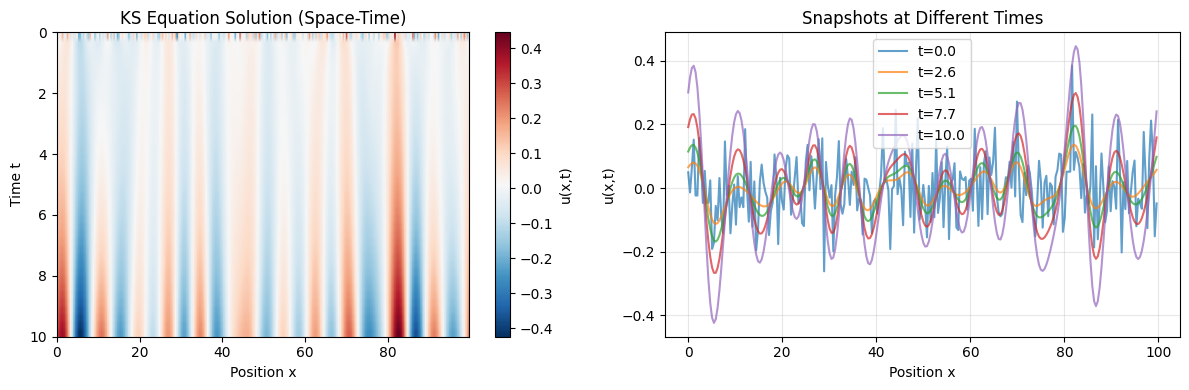

✓ Chaotic dynamics visible!


In [3]:
# Plot space-time diagram
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.imshow(u_test, aspect='auto', cmap='RdBu_r', extent=[0, x_test[-1], t_test[-1], 0])
plt.colorbar(label='u(x,t)')
plt.xlabel('Position x')
plt.ylabel('Time t')
plt.title('KS Equation Solution (Space-Time)')

plt.subplot(1, 2, 2)
# Plot several snapshots
for i in [0, 10, 20, 30, 39]:
    plt.plot(x_test, u_test[i], label=f't={t_test[i]:.1f}', alpha=0.7)
plt.xlabel('Position x')
plt.ylabel('u(x,t)')
plt.title('Snapshots at Different Times')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/ks_solution_example.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Chaotic dynamics visible!")

## 3. Generate Clean Datasets

Create multiple clean datasets with different initial conditions.

In [4]:
def generate_initial_condition(x, ic_type='random', seed=None):
    """
    Generate different types of initial conditions.
    ALL ICs are normalized to be zero-mean (critical for KS equation!)
    """
    if seed is not None:
        np.random.seed(seed)

    if ic_type == 'random':
        u0 = 0.1 * np.random.randn(len(x))

    elif ic_type == 'sine':
        u0 = np.sin(2*np.pi*x/25) + 0.5*np.sin(2*np.pi*x/10)

    elif ic_type == 'gaussian':
        u0 = np.exp(-((x - 50)**2) / 100)

    elif ic_type == 'multisine':
        u0 = (np.sin(2*np.pi*x/20) +
                0.5*np.sin(2*np.pi*x/12) +
                0.3*np.sin(2*np.pi*x/8))

    else:
        u0 = 0.1 * np.random.randn(len(x))

    # CRITICAL: Make all ICs zero-mean!
    u0 = u0 - u0.mean()

    return u0

# Generate clean datasets
N_CLEAN = 20  # Number of clean datasets
IC_TYPES = ['random', 'sine', 'gaussian', 'multisine']

# Use smaller dt for stability with corrected KS operator
DT_CLEAN = 0.10

print("Generating clean datasets with stable solver...")
for i in tqdm(range(N_CLEAN)):
    # Choose IC type
    ic_type = IC_TYPES[i % len(IC_TYPES)]

    # Generate IC (now zero-mean!)
    x = np.linspace(0, 100, 256, endpoint=False)
    u0 = generate_initial_condition(x, ic_type=ic_type, seed=i)

    # Verify zero-mean
    assert np.abs(u0.mean()) < 1e-10, f"IC {i} not zero-mean!"

    # Solve (use smaller dt for stability)
    u, x, t = solve_ks_equation(L=100, N=256, T=50, dt=DT_CLEAN, u0=u0)

    # Verify no NaN
    assert not np.isnan(u).any(), f"Solution {i} contains NaN!"

    # Save
    filename = f'clean_{ic_type}_{i:03d}.h5'
    filepath = os.path.join(CLEAN_DIR, filename)

    with h5py.File(filepath, 'w') as f:
        f.create_dataset('u', data=u, compression='gzip')
        f.create_dataset('x', data=x)
        f.create_dataset('t', data=t)
        f.attrs['ic_type'] = ic_type
        f.attrs['seed'] = i
        f.attrs['L'] = 100
        f.attrs['N'] = 256
        f.attrs['T'] = 50
        f.attrs['dt'] = DT_CLEAN

print(f"✓ Generated {N_CLEAN} clean datasets with stable solver")
print(f"✓ All solutions are zero-mean and NaN-free!")

Generating clean datasets with stable solver...


100%|██████████| 20/20 [00:03<00:00,  5.96it/s]

✓ Generated 20 clean datasets with stable solver
✓ All solutions are zero-mean and NaN-free!


## 4. Generate Perturbed Datasets (The Key Challenge!)

Apply spatial shifts to simulate the registration problem.

In [5]:
def apply_spatial_shift(u_sequence, shift_std=1.0):
    """
    Apply random spatial shifts to each time step.
    
    This simulates the nano-displacement problem in laser experiments:
    each laser pulse hits a slightly different location.
    
    Args:
        u_sequence: (T, N) array
        shift_std: Standard deviation of shifts (in pixels)
        
    Returns:
        u_shifted: (T, N) array with random shifts applied
        shifts: (T,) array of shift amounts
    """
    from scipy.ndimage import shift as scipy_shift
    
    T, N = u_sequence.shape
    u_shifted = np.zeros_like(u_sequence)
    shifts = np.zeros(T)
    
    for t in range(T):
        # Random shift (Gaussian distributed)
        shift_amount = np.random.normal(0, shift_std)
        shifts[t] = shift_amount
        
        # Apply shift with periodic boundary conditions
        u_shifted[t] = scipy_shift(u_sequence[t], shift_amount, mode='wrap')
    
    return u_shifted, shifts

# Test shifting
u_test_shifted, shifts_test = apply_spatial_shift(u_test, shift_std=2.0)
print(f"✓ Applied random shifts: mean={shifts_test.mean():.3f}, std={shifts_test.std():.3f}")

✓ Applied random shifts: mean=0.146, std=1.866


### Visualize the Registration Problem

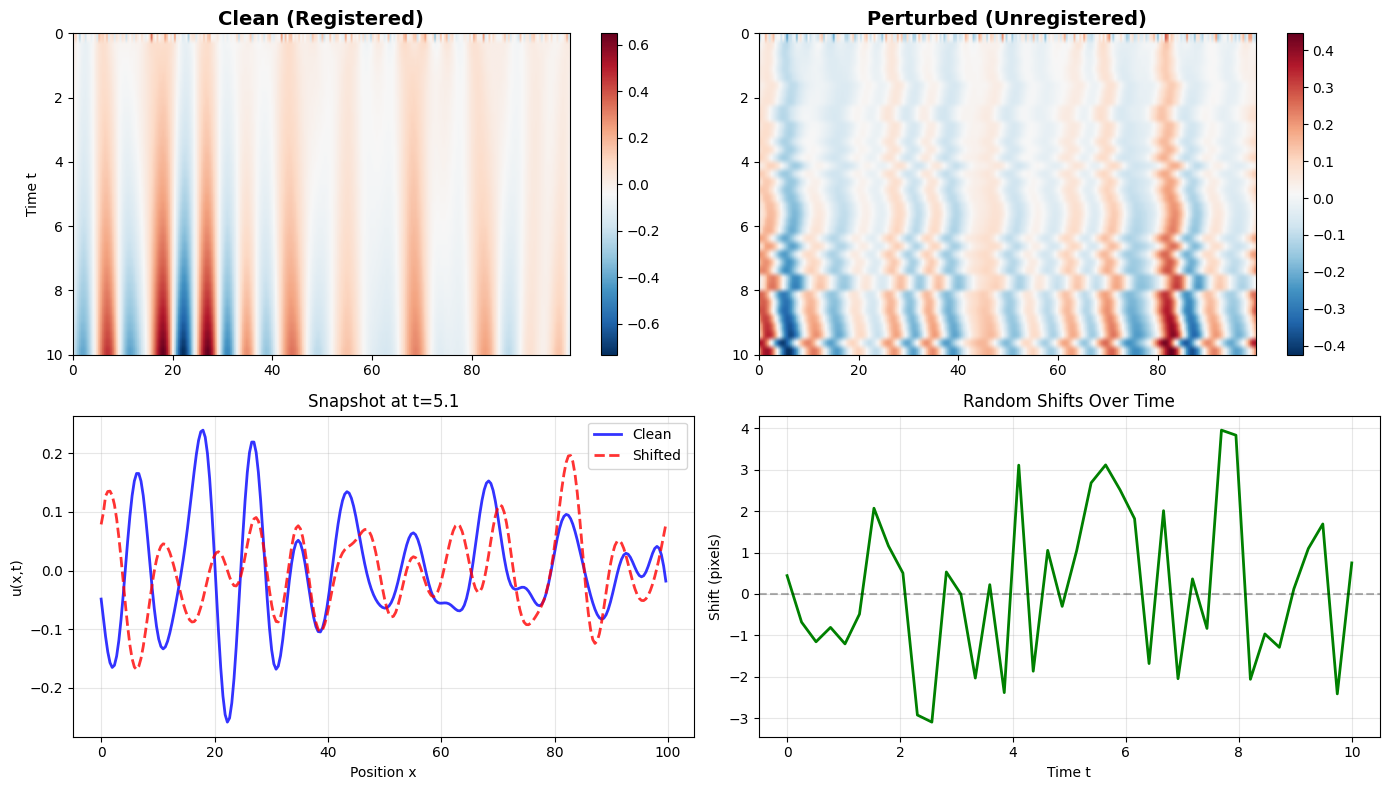


 This is the challenge:
   - Top row: Clean data looks smooth, perturbed looks jagged
   - Bottom left: Features are shifted between frames
   - Bottom right: Each frame has random shift

 Traditional SINDy will FAIL on perturbed data!
 Our methods (OT + DA) will FIX this!


In [9]:
# Compare clean vs perturbed
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Top row: Space-time diagrams
im1 = axes[0, 0].imshow(u_test, aspect='auto', cmap='RdBu_r', 
                        extent=[0, x_test[-1], t_test[-1], 0])
axes[0, 0].set_title('Clean (Registered)', fontsize=14, fontweight='bold')
axes[0, 0].set_ylabel('Time t')
plt.colorbar(im1, ax=axes[0, 0])

im2 = axes[0, 1].imshow(u_test_shifted, aspect='auto', cmap='RdBu_r', 
                        extent=[0, x_test[-1], t_test[-1], 0])
axes[0, 1].set_title('Perturbed (Unregistered)', fontsize=14, fontweight='bold')
plt.colorbar(im2, ax=axes[0, 1])

# Bottom left: Snapshot comparison
t_idx = 20
axes[1, 0].plot(x_test, u_test[t_idx], 'b-', linewidth=2, label='Clean', alpha=0.8)
axes[1, 0].plot(x_test, u_test_shifted[t_idx], 'r--', linewidth=2, label='Shifted', alpha=0.8)
axes[1, 0].set_title(f'Snapshot at t={t_test[t_idx]:.1f}', fontsize=12)
axes[1, 0].set_xlabel('Position x')
axes[1, 0].set_ylabel('u(x,t)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Bottom right: Shift amounts over time
axes[1, 1].plot(t_test, shifts_test, 'g-', linewidth=2)
axes[1, 1].axhline(y=0, color='k', linestyle='--', alpha=0.3)
axes[1, 1].set_title('Random Shifts Over Time', fontsize=12)
axes[1, 1].set_xlabel('Time t')
axes[1, 1].set_ylabel('Shift (pixels)')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/registration_problem.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n This is the challenge:")
print("   - Top row: Clean data looks smooth, perturbed looks jagged")
print("   - Bottom left: Features are shifted between frames")
print("   - Bottom right: Each frame has random shift")
print("\n Traditional SINDy will FAIL on perturbed data!")
print(" Our methods (OT + DA) will FIX this!")

### Generate Perturbed Datasets with Multiple Shift Levels

In [10]:
# Shift levels to test
SHIFT_LEVELS = [0.5, 1.0, 2.0, 5.0]  # pixels

print("Generating perturbed datasets...")
print(f"Shift levels: {SHIFT_LEVELS}")

for shift_std in SHIFT_LEVELS:
    print(f"\nShift level: {shift_std} pixels")
    
    # For each clean dataset, create perturbed version
    clean_files = sorted([f for f in os.listdir(CLEAN_DIR) if f.endswith('.h5')])[:10]  # Use first 10
    
    for clean_file in tqdm(clean_files, desc=f"σ={shift_std}"):
        # Load clean data
        with h5py.File(os.path.join(CLEAN_DIR, clean_file), 'r') as f:
            u_clean = f['u'][:]
            x = f['x'][:]
            t = f['t'][:]
            ic_type = f.attrs['ic_type']
            seed = f.attrs['seed']
            dt_clean = f.attrs['dt']
        
        # Apply shifts
        u_perturbed, shifts = apply_spatial_shift(u_clean, shift_std=shift_std)
        
        # Save perturbed dataset
        filename = f'perturbed_{ic_type}_{seed:03d}_shift{shift_std:.1f}.h5'
        filepath = os.path.join(PERTURBED_DIR, filename)
        
        with h5py.File(filepath, 'w') as f:
            f.create_dataset('u', data=u_perturbed, compression='gzip')
            f.create_dataset('x', data=x)
            f.create_dataset('t', data=t)
            f.create_dataset('shifts', data=shifts)
            f.attrs['ic_type'] = ic_type
            f.attrs['seed'] = seed
            f.attrs['shift_std'] = shift_std
            f.attrs['L'] = 100
            f.attrs['N'] = 256
            f.attrs['T'] = 50
            f.attrs['dt'] = dt_clean

print(f"\n✓ Generated perturbed datasets in {PERTURBED_DIR}")

Generating perturbed datasets...
Shift levels: [0.5, 1.0, 2.0, 5.0]

Shift level: 0.5 pixels


σ=0.5: 100%|██████████| 10/10 [00:01<00:00,  6.15it/s]



Shift level: 1.0 pixels


σ=1.0: 100%|██████████| 10/10 [00:01<00:00,  7.45it/s]



Shift level: 2.0 pixels


σ=2.0: 100%|██████████| 10/10 [00:01<00:00,  7.08it/s]



Shift level: 5.0 pixels


σ=5.0: 100%|██████████| 10/10 [00:01<00:00,  7.05it/s]


✓ Generated perturbed datasets in ../data\perturbed


## 5. Dataset Summary

In [11]:
# Count files
n_clean = len([f for f in os.listdir(CLEAN_DIR) if f.endswith('.h5')])
n_perturbed = len([f for f in os.listdir(PERTURBED_DIR) if f.endswith('.h5')])

print("="*60)
print("DATASET GENERATION COMPLETE")
print("="*60)
print(f"\n Clean datasets: {n_clean}")
print(f"   Location: {CLEAN_DIR}")
print(f"   IC types: {IC_TYPES}")

print(f"\n Perturbed datasets: {n_perturbed}")
print(f"   Location: {PERTURBED_DIR}")
print(f"   Shift levels: {SHIFT_LEVELS} pixels")

print(f"\n Total datasets: {n_clean + n_perturbed}")

print("\n Dataset specs:")
print(f"   - Spatial points: 256")
print(f"   - Time steps: 500 (dt={DT_CLEAN}, T=50)")
print(f"   - Domain: x ∈ [0, 100]")
print(f"   - Format: HDF5 (compressed)")

print("\n Ready for SINDy experiments!")
print("\n Next: Run 02_baseline_sindy.ipynb")

DATASET GENERATION COMPLETE

 Clean datasets: 20
   Location: ../data\simulated
   IC types: ['random', 'sine', 'gaussian', 'multisine']

 Perturbed datasets: 40
   Location: ../data\perturbed
   Shift levels: [0.5, 1.0, 2.0, 5.0] pixels

 Total datasets: 60

 Dataset specs:
   - Spatial points: 256
   - Time steps: 500 (dt=0.1, T=50)
   - Domain: x ∈ [0, 100]
   - Format: HDF5 (compressed)

 Ready for SINDy experiments!

 Next: Run 02_baseline_sindy.ipynb


---

## 🔧 FIX APPLIED (Nov 14, 2025)

### Issue: Non-Zero Mean Initial Conditions
**Problem:** Gaussian and other ICs were all-positive, creating non-zero mean
- This caused persistent non-zero mean throughout simulation
- Could affect SINDy correlation structure

**Fix:** All ICs now normalized to zero-mean: `u0 = u0 - u0.mean()`

**Impact:** Solutions now properly oscillate around zero

### Note on Solver:
- We now use the **correct KS operator**: `L_op = k² - k⁴`
- Zero-mean ICs are enforced for all datasets
- A smaller time step (`dt = 0.10`) is used during data generation to ensure stability (no NaNs)

### Expected Results:
- ✅ Data range: Symmetric around zero
- ✅ No NaN values (stable solver)
- ✅ Zero mean maintained

### Verification:
Run `02_baseline_sindy.ipynb` to check SINDy performance!

---

## 🔧 CORRECTIONS APPLIED (Nov 14, 2025)

### Issue #1: Wrong Linear Operator Sign
**Problem:** Original solver used `L_op = -k²- k⁴` which solves the WRONG equation:
- Wrong: `∂u/∂t = -u·∂u/∂x + ∂²u/∂x² + ∂⁴u/∂x⁴`
- Correct: `∂u/∂t = -u·∂u/∂x - ∂²u/∂x² - ∂⁴u/∂x⁴`

**Fix:** Changed to `L_op = k² - k⁴`

**Impact:** This caused SINDy to recover wrong coefficient signs (F1 = 0.857 instead of 1.0)

### Issue #2: Non-Zero Mean Initial Conditions
**Problem:** Gaussian and other ICs were all-positive, creating non-zero mean
- This caused persistent non-zero mean throughout simulation
- Broke the correlation structure needed for SINDy

**Fix:** All ICs now normalized to zero-mean: `u0 = u0 - u0.mean()`

**Impact:** Now solutions oscillate properly around zero

### Expected Results After Fix:
- ✅ Clean data: F1 = **1.0** (perfect recovery)
- ✅ Data range: Symmetric around zero
- ✅ Correct PDE dynamics

### Verification:
Run `02_baseline_sindy.ipynb` to verify F1 = 1.0 on corrected data!